In [1]:
import tensorflow

In [2]:
from tensorflow. keras import Sequential
from tensorflow. keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense

In [3]:
target_shape=(64,64,3)

In [4]:
cnn_model=Sequential()

In [5]:
cnn_model.add(Input(shape=target_shape))

In [6]:
conv_layer=Conv2D(filters=32,
                  kernel_size=(3,3),
                  strides=(1,1),
                  kernel_initializer= "glorot_uniform", 
                  activation="relu") 
cnn_model.add(conv_layer)
print("add conv layer")

add conv layer


In [7]:
maxpool_layer=MaxPool2D(pool_size=(2,2),strides=(2,2))
cnn_model.add(maxpool_layer)
print("add Maxpooling layer")

add Maxpooling layer


In [8]:
flatten_layer=Flatten()
cnn_model.add(flatten_layer)
print("add flatten_layer")

add flatten_layer


In [9]:
fc_layer=Dense(units=200,
               kernel_initializer="glorot_uniform",
               bias_initializer="glorot_uniform",
               activation="relu"
              )
cnn_model.add(fc_layer)
print("add fc layer")
               

add fc layer


In [10]:
output_layer=Dense(units=1,
                   kernel_initializer="glorot_uniform",
                   bias_initializer="glorot_uniform",
                   activation="sigmoid")
cnn_model.add(output_layer)
print("output Layer")

output Layer


In [16]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 30752)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 200)                 │       6,150,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,151,697 (23.47 MB)

 Trainable params: 6,151,697 (23.47 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
pip install pydot

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [13]:
pip install plot_model

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install graphviz

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [15]:
from tensorflow. keras.utils import plot_model
plot_model(cnn_model,
           show_shapes=True,
           show_layer_names=True,.
           show_dtype=True,
           show_layer_activations=True,
           expand_nested=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [18]:
from tensorflow. keras.optimizers import Adam
adam=Adam(learning_rate=0.01)
cnn_model.compile(loss="binary_crossentropy", optimizer="adam",metrics=["accuracy"])

In [19]:
from tensorflow. keras. preprocessing.image import ImageDataGenerator
train_gen=ImageDataGenerator(horizontal_flip=True,
                      rotation_range=0.3,
                      shear_range=0.1,
                      zoom_range=0.01,
                      rescale=1/255.0)
test_gen=ImageDataGenerator(rescale=1/255.0)

In [20]:
train_data=train_gen.flow_from_directory(
    "C:\\Users\\anant\\Downloads\\cnn_dataset\\cnn_dataset\\training_set",  
    target_size=target_shape[:2], 
    color_mode="rgb",    
    class_mode="binary",
    batch_size=64,  
    shuffle=True  
)

Found 8000 images belonging to 2 classes.


In [21]:
test_data=train_gen.flow_from_directory(
    "C:\\Users\\anant\\Downloads\\cnn_dataset\\cnn_dataset\\test_set",   
    target_size=target_shape[:2],
    color_mode="rgb",   
    class_mode="binary", 
    batch_size=64, 
    shuffle=False  
)

Found 2000 images belonging to 2 classes.


In [22]:
print("class labels:",train_data.class_indices)
print("Number of training samples:",train_data.samples)
print("Number of test samples:",test_data.samples)

class labels: {'cats': 0, 'dogs': 1}
Number of training samples: 8000
Number of test samples: 2000


In [23]:
train_data[1]

(array([[[[5.8154011e-01, 5.9722638e-01, 5.9330481e-01],
          [2.6400855e-01, 2.7969483e-01, 2.7577326e-01],
          [5.3067195e-01, 5.4635823e-01, 5.4243666e-01],
          ...,
          [1.7394151e-01, 2.1229656e-01, 1.7617790e-01],
          [4.1987342e-01, 4.5037732e-01, 4.0683031e-01],
          [2.0039654e-01, 2.2388189e-01, 1.7683776e-01]],
 
         [[5.5790037e-01, 5.7358664e-01, 5.6966507e-01],
          [3.0428958e-01, 3.1997588e-01, 3.1605428e-01],
          [5.5013585e-01, 5.6582212e-01, 5.6190056e-01],
          ...,
          [2.7820688e-01, 3.0522546e-01, 2.7304807e-01],
          [2.1867599e-01, 2.4092677e-01, 2.0131083e-01],
          [3.0630562e-01, 3.1805339e-01, 2.7491611e-01]],
 
         [[6.1364138e-01, 6.2932765e-01, 6.2540609e-01],
          [3.4599957e-01, 3.6168584e-01, 3.5776427e-01],
          [5.6019098e-01, 5.7587725e-01, 5.7195568e-01],
          ...,
          [3.1143638e-01, 3.3021784e-01, 3.0196935e-01],
          [3.5917687e-01, 3.7050438e-

In [24]:
test_data[1]

(array([[[[3.25490206e-01, 3.01960796e-01, 2.39215702e-01],
          [3.25490206e-01, 3.01960796e-01, 2.39215702e-01],
          [3.28429133e-01, 3.04899693e-01, 2.42154583e-01],
          ...,
          [3.33945096e-01, 3.06494087e-01, 2.35905841e-01],
          [3.40848774e-01, 3.13397795e-01, 2.42809579e-01],
          [3.37254912e-01, 3.09803933e-01, 2.39215702e-01]],
 
         [[3.29197437e-01, 3.05668026e-01, 2.42922932e-01],
          [3.23669016e-01, 3.00139576e-01, 2.37394467e-01],
          [3.30294937e-01, 3.06765527e-01, 2.44020432e-01],
          ...,
          [3.33966553e-01, 3.06515574e-01, 2.35927328e-01],
          [3.41324091e-01, 3.13873112e-01, 2.43284881e-01],
          [3.42858016e-01, 3.15407038e-01, 2.44818792e-01]],
 
         [[3.29411775e-01, 3.05882365e-01, 2.43137270e-01],
          [3.29101801e-01, 3.05572391e-01, 2.42827296e-01],
          [3.26676965e-01, 3.03147554e-01, 2.40402445e-01],
          ...,
          [3.33988041e-01, 3.06537062e-01, 2.3594

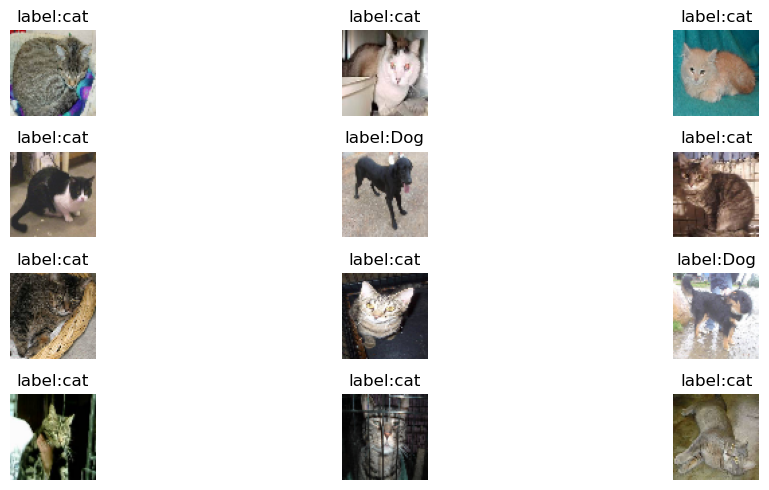

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
for idx,each_batch in enumerate(train_data,1):
    X,y = each_batch
    plt.subplot(4,3,idx)
    plt.imshow(X[0])
    plt.title(f"label:{'Dog' if y[0] ==1 else 'cat'}")
    plt.axis("off")
    if idx >= 12:
        break
plt.tight_layout()
plt.show()

In [26]:
history=cnn_model.fit(train_data,epochs=20)

C:\Users\anant\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.5042 - loss: 0.8545
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 62s 495ms/step - accuracy: 0.6420 - loss: 0.6351 
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 60s 483ms/step - accuracy: 0.6852 - loss: 0.5935 
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 61s 491ms/step - accuracy: 0.7116 - loss: 0.5631 
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 62s 497ms/step - accuracy: 0.7336 - loss: 0.5377
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 502ms/step - accuracy: 0.7511 - loss: 0.5118
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 455s 4s/step - accuracy: 0.7586 - loss: 0.4974  
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 522ms/step - accuracy: 0.7697 - loss: 0.4858 
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 516ms/step - accuracy: 0.7692 - loss: 0.4717 
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 510ms/step - accuracy: 0.7886 - loss: 0.4579 
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 507ms/step - accuracy: 0.7971 - loss: 0.4426 
Epoch 12/20
12

In [28]:
y_pred=cnn_model.predict(test_data)

32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step   


In [29]:
y_test=test_data.classes
y_test

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [30]:
y_pred = y_pred > 0.5
y_Pred=y_pred.astype("int")
y_pred

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [ True]])

In [31]:
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7575
              precision    recall  f1-score   support

           0       0.73      0.81      0.77      1000
           1       0.79      0.70      0.74      1000

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.76      0.76      0.76      2000



In [33]:
cnn_model=cnn_model.save("cat_dog_model_predict.keras")
print("this model is saved")

this model is saved


In [34]:
from tensorflow. keras.models import load_model
import numpy as np
import cv2

In [35]:
cnn_model=load_model("cat_dog_model_predict.keras")
print("this model is loaded")

this model is loaded


In [36]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 30752)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 200)                 │       6,150,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,455,093 (70.40 MB)

 Trainable params: 6,151,697 (23.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,303,396 (46.93 MB)

In [52]:
img_path=("C:\\Users\\anant\\Downloads\\dog.jpg")
image=cv2.imread(img_path)
print("image is loaded")
if image is None :
    print("image is not defined" )
    print("again load image properly")
else:
    print(f"image is load successfylly: {image.shape}")



image is loaded
image is load successfylly: (400, 500, 3)


In [57]:
image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(f"image is converted:{image.shape}")

image is converted:(400, 500, 3)


In [63]:
image=cv2.resize(image,(64,64))
print(f"image is reshape:{image.shape}")

image is reshape:(64, 64, 3)


In [66]:
image=image*(1/255.0)
print("image is normalized")
print(f"image is loded :{image.min():.3f} to {image.max():.3f}")

image is normalized
image is loded :0.000 to 1.000


In [81]:
image

array([[[[0.44705882, 0.49803922, 0.54117647],
         [0.57647059, 0.69803922, 0.79607843],
         [0.58431373, 0.77254902, 0.81176471],
         ...,
         [0.56078431, 0.7372549 , 0.69411765],
         [0.76862745, 0.85490196, 0.82352941],
         [0.67058824, 0.76470588, 0.76078431]],

        [[0.65490196, 0.70980392, 0.77254902],
         [0.34901961, 0.5254902 , 0.4       ],
         [0.70196078, 0.83529412, 0.94117647],
         ...,
         [0.82352941, 0.92156863, 0.91764706],
         [0.67058824, 0.75294118, 0.7254902 ],
         [0.65490196, 0.78823529, 0.79215686]],

        [[0.37647059, 0.54117647, 0.32941176],
         [0.38039216, 0.60392157, 0.4745098 ],
         [0.54509804, 0.70588235, 0.65098039],
         ...,
         [0.61568627, 0.78823529, 0.72156863],
         [0.61568627, 0.7372549 , 0.65882353],
         [0.58431373, 0.67058824, 0.62352941]],

        ...,

        [[0.51372549, 0.6       , 0.56862745],
         [0.81176471, 0.91764706, 0.94901961]

In [71]:
image=np.array([image])
print(f"image dimensions are added:{image.shape}")
print(" image ready to prediction")

image dimensions are added:(1, 64, 64, 3)
 image ready to prediction


In [72]:
prediction=cnn_model.predict(image,verbose=False)
print(f"image prediction is done :{prediction[0][0]:.4f}")
print("values close 0= cat, values closer 1= cat")

image prediction is done :0.9954
values close 0= cat, values closer 1= cat


In [80]:
binary_prediction=prediction>0.5
binary_prediction=binary_prediction.astype("int")

predicted_class=" Dog" if binary_prediction[0][0] == 1 else "cat"
confidence=prediction[0][0] if binary_prediction[0][0] == 1 else 1-prediction[0][0]

print(binary_prediction)
print(predicted_class)
print(f"confidence:{confidence:.4f} ({confidence*100:.1f}%)")

[[1]]
 Dog
confidence:0.9954 (99.5%)


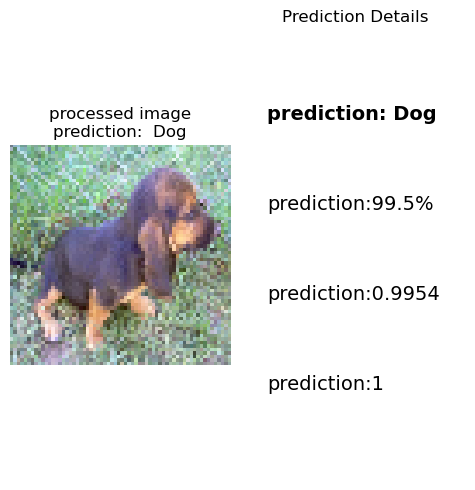

In [87]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.subplot(1,2,1)
plt.imshow(image[0])
plt.title(f"processed image\nprediction: {predicted_class}")
plt.axis("off")

plt.subplot(1,2,2)
plt.text(0.1, 0.8, f"prediction:{predicted_class}",fontsize=14,fontweight="bold")
plt.text(0.1, 0.6, f"prediction:{confidence*100:.1f}%",fontsize=14)
plt.text(0.1, 0.4, f"prediction:{prediction[0][0]:.4f}",fontsize=14)
plt.text(0.1, 0.2, f"prediction:{binary_prediction[0][0]}",fontsize=14)
plt.xlim(0,1)
plt.ylim(0,1)
plt.axis("off")
plt.title("Prediction Details")

plt.tight_layout()
plt.show()
